In [1]:
import sys
import os

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.data_preprocessing import load_data, preprocess_data
from src.train_model import train_baseline_model, train_optimized_model
from src.evaluate_model import evaluate
from src.advanced_models import train_xgboost
from src.feature_importance import plot_feature_importance
from src.visualisations import plot_roc_curve, plot_model_performance
from src.eda import (
    plot_churn_distribution,
    plot_numerical_features,
    plot_correlation_matrix,
    plot_boxplots
)
from src.model_comparison import compare_models

In [3]:
df = load_data("../data/telco_churn.csv")

df.head()

,scustomerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   scustomerID       7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df.isnull().sum()
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

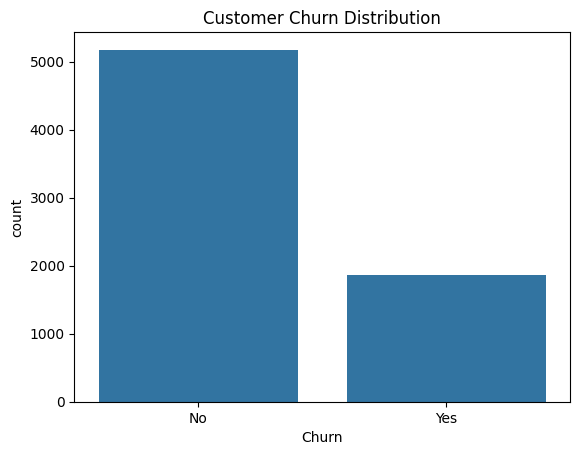

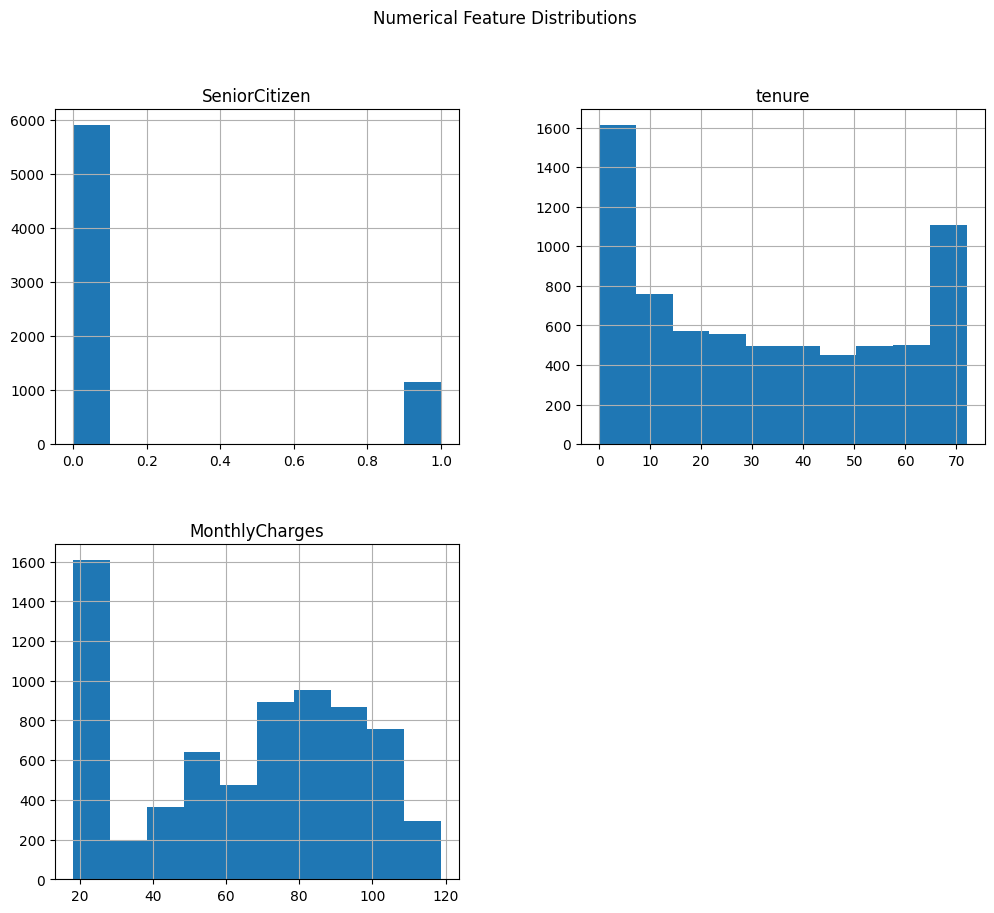

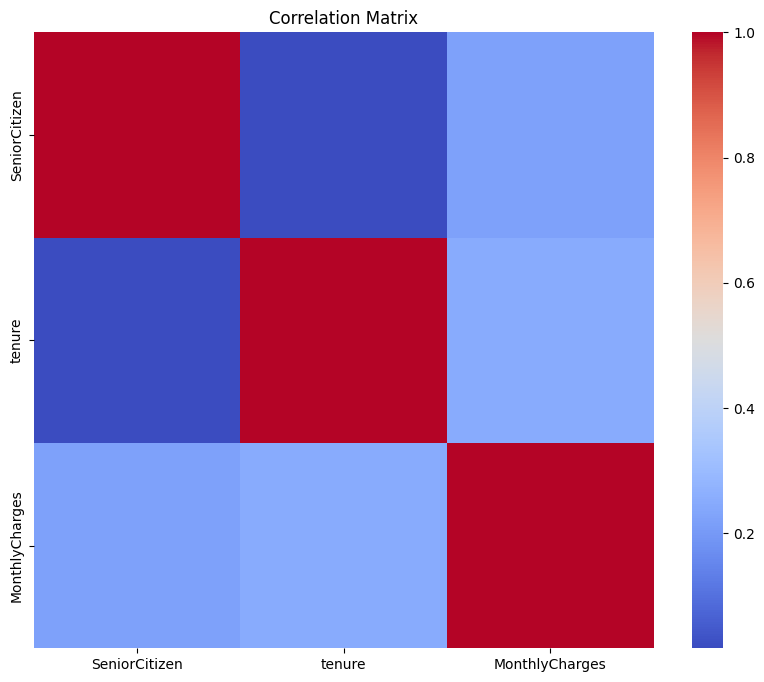

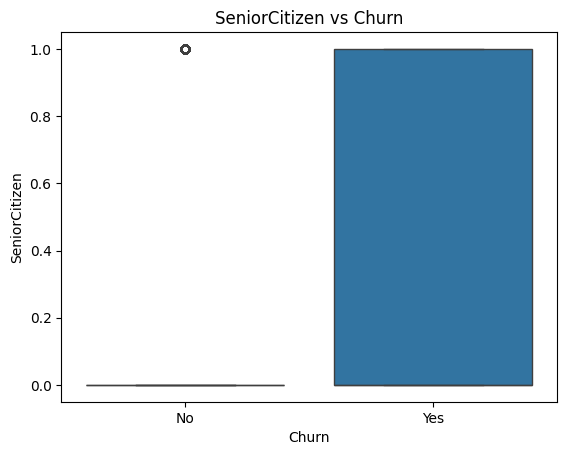

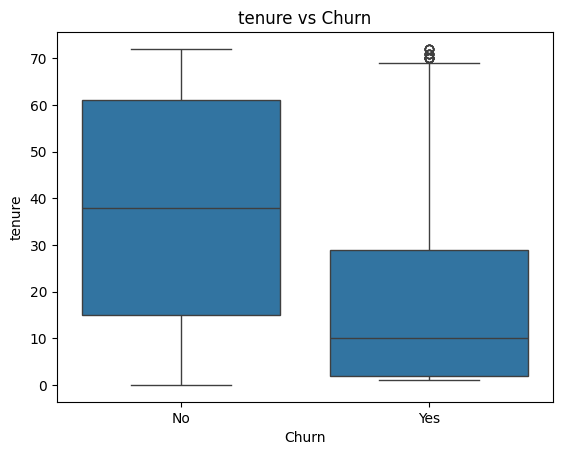

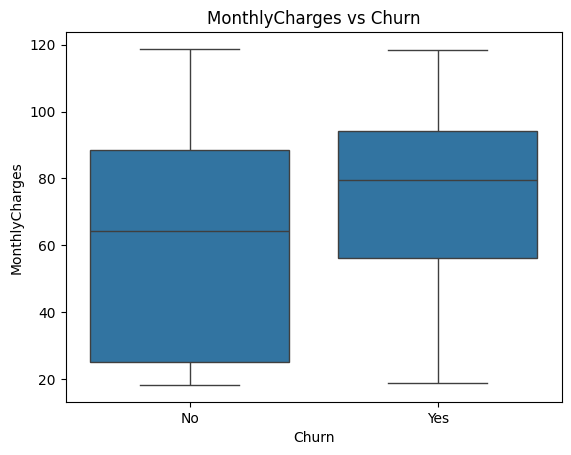

In [6]:
plot_churn_distribution(df)
plot_numerical_features(df)
plot_correlation_matrix(df)
plot_boxplots(df)

In [7]:
X_train, X_test, y_train, y_test = preprocess_data(df)

Dropping high-cardinality columns: ['scustomerID']
Final shapes -> X: (7032, 30), y: (7032,)


c:\Users\dell\Downloads\AI_Customer_Churn_Project\src\data_preprocessing.py:34: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = df["Churn"].replace({"Yes": 1, "No": 0})


In [8]:
baseline_model = train_baseline_model(X_train, y_train)
evaluate(baseline_model, X_test, y_test)

Accuracy: 0.7270788912579957
ROC AUC: 0.7484625021354138
Confusion Matrix:
[[726 307]
 [ 77 297]]

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



c:\Users\dell\Downloads\AI_Customer_Churn_Project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
optimized_model = train_optimized_model(X_train, y_train)
evaluate(optimized_model, X_test, y_test)

Accuracy: 0.7292110874200426
ROC AUC: 0.7507674547421715
Confusion Matrix:
[[728 305]
 [ 76 298]]

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407



In [10]:
xgb_model = train_xgboost(X_train, y_train)
evaluate(xgb_model, X_test, y_test)

Accuracy: 0.7931769722814499
ROC AUC: 0.7064841513477697
Confusion Matrix:
[[921 112]
 [179 195]]

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.64      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



c:\Users\dell\Downloads\AI_Customer_Churn_Project\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:23:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [11]:
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": baseline_model,
    "Random Forest": optimized_model,
    "XGBoost": xgb_model
}

results_df = compare_models(models, X_test, y_test)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.727079,0.491722,0.794118,0.607362
1,Random Forest,0.729211,0.494196,0.796791,0.610031
2,XGBoost,0.793177,0.635179,0.521390,0.572687


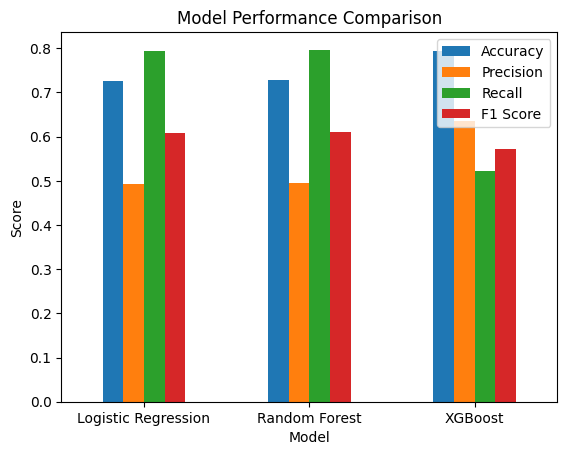

In [12]:
plot_model_performance(results_df)

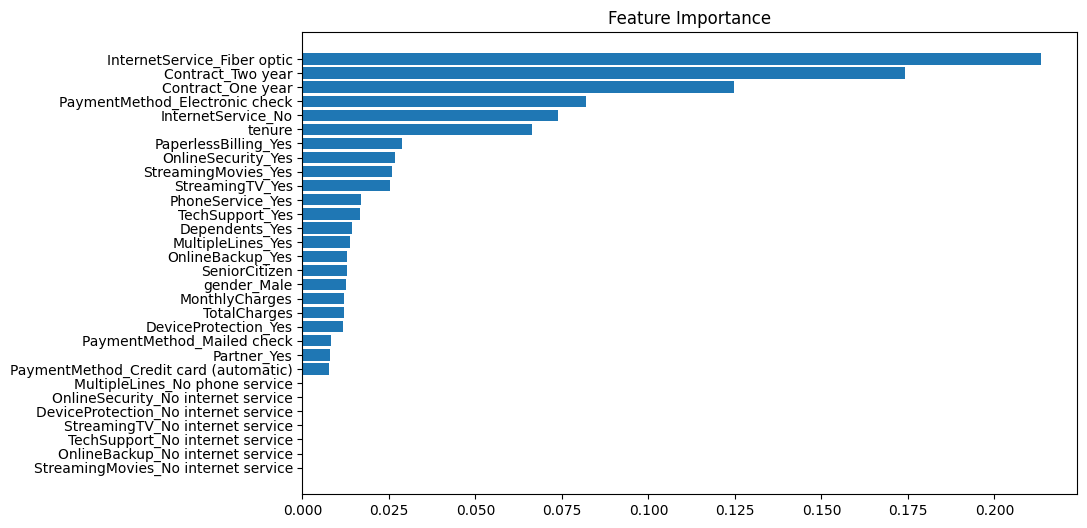

In [13]:

feature_names = X_train.columns

plot_feature_importance(xgb_model, feature_names)

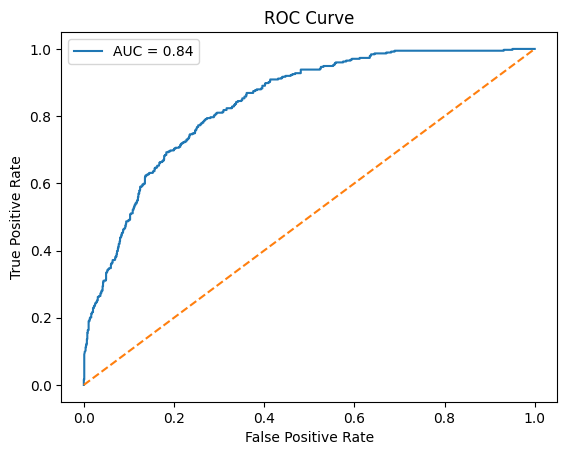

In [14]:
plot_roc_curve(xgb_model, X_test, y_test)

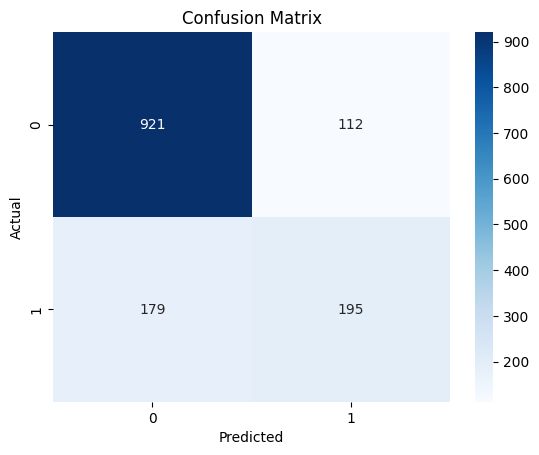

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

preds = xgb_model.predict(X_test)

cm = confusion_matrix(y_test, preds)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [16]:
probs = xgb_model.predict_proba(X_test)[:, 1]

df_probs = pd.DataFrame({
    "Actual": y_test,
    "Predicted_Probability": probs
})

df_probs.head()

,Actual,Predicted_Probability
974,0,0.011736
619,0,0.627127
4289,0,0.016332
3721,1,0.125068
4533,0,0.119970


In [17]:
df_probs.sort_values(by="Predicted_Probability", ascending=False).head(10)

,Actual,Predicted_Probability
3380,1,0.942468
4585,1,0.933093
6240,1,0.904627
2631,1,0.899668
2753,1,0.890679
2464,1,0.887735
3159,0,0.886842
383,1,0.883326
6633,1,0.881731
1731,1,0.881153


In [18]:
import numpy as np

thresholds = np.arange(0.1, 0.9, 0.1)

for t in thresholds:
    preds = (probs > t).astype(int)
    acc = (preds == y_test).mean()
    print(f"Threshold: {t:.1f}, Accuracy: {acc:.3f}")

Threshold: 0.1, Accuracy: 0.611
Threshold: 0.2, Accuracy: 0.699
Threshold: 0.3, Accuracy: 0.748
Threshold: 0.4, Accuracy: 0.787
Threshold: 0.5, Accuracy: 0.793
Threshold: 0.6, Accuracy: 0.785
Threshold: 0.7, Accuracy: 0.779
Threshold: 0.8, Accuracy: 0.765


In [19]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(xgb_model, X_train, y_train, cv=5)

print("Cross Validation Scores:", scores)
print("Mean Score:", scores.mean())

c:\Users\dell\Downloads\AI_Customer_Churn_Project\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:23:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\dell\Downloads\AI_Customer_Churn_Project\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:23:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\dell\Downloads\AI_Customer_Churn_Project\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:23:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\dell\Downloads\AI_Customer_Churn_Project\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:23:04] WARNING: C:\actio

Cross Validation Scores: [0.79377778 0.83377778 0.79644444 0.79377778 0.78844444]
Mean Score: 0.8012444444444444


c:\Users\dell\Downloads\AI_Customer_Churn_Project\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:23:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [20]:
X_train, X_test, y_train, y_test = preprocess_data(df)

c:\Users\dell\Downloads\AI_Customer_Churn_Project\src\data_preprocessing.py:34: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = df["Churn"].replace({"Yes": 1, "No": 0})


Dropping high-cardinality columns: ['scustomerID']
Final shapes -> X: (7032, 30), y: (7032,)


In [21]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("Number of features:", len(X_train.columns))

X_train shape: (5625, 30)
X_test shape: (1407, 30)
y_train shape: (5625,)
y_test shape: (1407,)
Number of features: 30


In [22]:
from src.save_model import save_model

save_model(xgb_model, "churn_model.pkl")

In [23]:
from sklearn.metrics import roc_auc_score

# Logistic Regression
y_pred_lr = baseline_model.predict(X_test)
y_proba_lr = baseline_model.predict_proba(X_test)[:, 1]

print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, y_proba_lr))

# XGBoost
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

Logistic Regression ROC-AUC: 0.8359290473207676
XGBoost ROC-AUC: 0.8387697946379113


In [24]:
print("Pipeline executed successfully.")
print("Best model: XGBoost")
print("Project complete.")

Pipeline executed successfully.
Best model: XGBoost
Project complete.
